# 1: Environment Setup & Dependencies

## Project Overview

**Project Name:** Data Lake Integration & Analytics Automation   

**Project Description:**  
This project simulates a corporate **AP/GL Data Lake Integration and Analytics Pipeline** using public financial datasets.  

**Objectives:**
- Build Python + SQL ETL pipelines to ingest, clean, consolidate, and validate transaction data
- Implement SQL validation rules in **MySQL** (duplicates, missing values, negative amounts) 
- Create **Power BI dashboards** to monitor data quality, pipeline performance, and analytics metrics  
- Demonstrate handling of “dirty data” to simulate real-world enterprise data lakes

**Metrics to visualize (on PowerBI):**
- Data quality KPIs:
  - Missing values per column
  - Duplicate transactions
  - Negative transaction counts
- Pipeline performance:
  - Transactions ingested per day
  - Records passed/failed validation
- Analytics insights:
  - Total spend per vendor, MCC category, or cost center
  - Average transaction amount
  - Fraud detection metrics (if using train_fraud_labels.json)

**Datasets:** (available on: https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets)
- `transactions_data.csv` → transaction records  
- `cards_data.csv` → card info for cost center mapping  
- `users_data.csv` → customer demographic info  
- `mcc_codes.json` → transaction categorization  
- `train_fraud_labels.json` → optional fraud/anomaly labels
---


# 2: Data Ingestion & Cleaning
**Objectives:**
1) Load all 5 datasets into Jupyter
2) Standardize and rename columns to AP/GL schema
3) Clean financial fields (amount, currency, dates)
4) Integrate datasets (transactions + cards + users + MCC + fraud labels)
5) Generate synthetic fields (invoice_number, currency, cost_center)
6) Inject controlled dirty data for validation demo
7) Save cleaned version

## 2.1: Load all datasets

In this step, we read all CSV and JSON datasets into Python pandas DataFrames for processing.
- `transactions_data.csv` → main transactions
- `cards_data.csv` → card info, for cost center mapping
- `users_data.csv` → customer info, for enrichment
- `mcc_codes.json` → merchant category codes
- `train_fraud_labels.json` → optional fraud labels

In [1]:
import pandas as pd
import numpy as np
import json
import os

# Ensure folders exist
folders = ["data/raw", "data/processed", "data/cleaned"]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

## Load CSVs
# Transactions (+ Rename)
transactions_df = pd.read_csv("data/raw/transactions_data.csv")

# Cards
cards_df = pd.read_csv("data/raw/cards_data.csv")
# Users
users_df = pd.read_csv("data/raw/users_data.csv")

## Load JSON files
# MCC Codes
with open("data/raw/mcc_codes.json") as f:
    mcc_codes = json.load(f)
mcc_df = pd.DataFrame(list(mcc_codes.items()), columns=['mcc_code', 'mcc_description'])

# Fraud Labels
with open("data/raw/train_fraud_labels.json") as f:
    fraud_labels = json.load(f)
fraud_df = pd.DataFrame(list(fraud_labels['target'].items()), columns=['transaction_id', 'fraud_flag'])

# Quick check
print("Transactions:", transactions_df.head(3))
print("\nCards:", cards_df.head(3))
print("\nUsers:", users_df.head(3))
print("\nMCC Codes:", mcc_df.head(3))
print("\nFraud Labels:", fraud_df.head(3))

Transactions:         id                 date  client_id  card_id   amount  \
0  7475327  2010-01-01 00:01:00       1556     2972  $-77.00   
1  7475328  2010-01-01 00:02:00        561     4575   $14.57   
2  7475329  2010-01-01 00:02:00       1129      102   $80.00   

            use_chip  merchant_id merchant_city merchant_state      zip   mcc  \
0  Swipe Transaction        59935        Beulah             ND  58523.0  5499   
1  Swipe Transaction        67570    Bettendorf             IA  52722.0  5311   
2  Swipe Transaction        27092         Vista             CA  92084.0  4829   

  errors  
0    NaN  
1    NaN  
2    NaN  

Cards:      id  client_id card_brand card_type       card_number  expires  cvv  \
0  4524        825       Visa     Debit  4344676511950444  12/2022  623   
1  2731        825       Visa     Debit  4956965974959986  12/2020  393   
2  3701        825       Visa     Debit  4582313478255491  02/2024  719   

  has_chip  num_cards_issued credit_limit acct_open

## 2.2: Standardize & Rename Columns to AP/GL Schema

We map raw banking fields into enterprise AP/GL structure:

**transactions_data.csv:**

| Original | New |
|----------|------|
| id | transaction_id |
| date | transaction_date |
| use_chip | payment_method |
| merchant_id | vendor_id |
| mcc | mcc_code |

We simulate corporate ledger fields for analytics readiness.

In [2]:
# Rename transactions columns
transactions_df = transactions_df.rename(columns={
    "id": "transaction_id",
    "date": "transaction_date",
    "use_chip": "payment_method",
    "merchant_id": "vendor_id",
    "mcc": "mcc_code"
})

transactions_df.head()

,transaction_id,transaction_date,client_id,card_id,amount,payment_method,vendor_id,merchant_city,merchant_state,zip,mcc_code,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


## 2.3: Standardize and Clean Financial Fields

We standardize:

- Convert transaction_date and acct_open_date → datetime 
- Remove "$" from all datasets (if any) → float
- Ensure mcc_code is string

In [3]:
# Convert `transaction_date` and `acct_open_date` to datetime
transactions_df["transaction_date"] = pd.to_datetime(transactions_df["transaction_date"], errors="coerce")
cards_df["acct_open_date"] = pd.to_datetime(cards_df["acct_open_date"], errors="coerce")

# Clean amount (Remove $)
datasets = {
    "transactions": transactions_df,
    "cards": cards_df,
    "users": users_df
}
for name, df in datasets.items():
    for col in df.columns:
        if df[col].dtype == "object":
            if df[col].str.contains(r"\$", na=False).any():
                df[col] = (
                    df[col]
                    .replace(r"[\$,]", "", regex=True)
                    .astype(float)
                )

# Ensure mcc is string
transactions_df["mcc_code"] = transactions_df["mcc_code"].astype(str)

transactions_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19784\640649011.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cards_df["acct_open_date"] = pd.to_datetime(cards_df["acct_open_date"], errors="coerce")


,transaction_id,transaction_date,client_id,card_id,amount,payment_method,vendor_id,merchant_city,merchant_state,zip,mcc_code,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


# 2.4: Data Integration (Simulating Data Lake Consolidation)

We integrate:

- transactions + cards (via left:"card_id", right:"id")
- transactions + users (via left:"client_id", right:"id")
- transactions + MCC codes (category mapping)
- transactions + fraud labels

This simulates data lake consolidation.

In [4]:
# Join transactions with cards
cleaned_df = transactions_df.merge(cards_df, left_on="card_id", right_on="id", how="left", suffixes=("", "_card"))

# Join with users
cleaned_df  = cleaned_df.merge(users_df, left_on="client_id", right_on="id", how="left", suffixes=("", "_user"))

# Map MCC descriptions
cleaned_df ["mcc_description"] = cleaned_df["mcc_code"].map(mcc_codes)

# Map fraud labels
fraud_map = fraud_labels.get("target", {})
cleaned_df ["fraud_flag"] = cleaned_df["transaction_id"].astype(str).map(fraud_map)

cleaned_df.head()

,transaction_id,transaction_date,client_id,card_id,amount,payment_method,vendor_id,merchant_city,merchant_state,zip,...,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,mcc_description,fraud_flag
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,594 Mountain View Street,46.80,-100.76,23679.0,48277.0,110153.0,740,4,Miscellaneous Food Stores,No
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,604 Pine Street,40.80,-91.12,18076.0,36853.0,112139.0,834,5,Department Stores,No
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,2379 Forest Lane,33.18,-117.29,16894.0,34449.0,36540.0,686,3,Money Transfer,No
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,...,903 Hill Boulevard,41.42,-87.35,26168.0,53350.0,128676.0,685,5,Money Transfer,NaN
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,...,166 River Drive,38.86,-76.60,33529.0,68362.0,96182.0,711,2,Drinking Places (Alcoholic Beverages),No


## 2.5: Generate Synthetic Enterprise Fields

To simulate corporate AP/GL:

- invoice_number → sequential INV-00001
- currency → default USD
- cost_center → derived from card_type

In [5]:
# Generate invoice numbers
cleaned_df["invoice_number"] = ["INV-" + str(i).zfill(6) for i in range(1, len(cleaned_df)+1)]

# Add currency
cleaned_df["currency"] = "USD"

# Generate cost center from card_type
cleaned_df["cost_center"] = cleaned_df["card_type"].fillna("Unknown")

print(cleaned_df.head())
print(cleaned_df.shape)

   transaction_id    transaction_date  client_id  card_id  amount  \
0         7475327 2010-01-01 00:01:00       1556     2972  -77.00   
1         7475328 2010-01-01 00:02:00        561     4575   14.57   
2         7475329 2010-01-01 00:02:00       1129      102   80.00   
3         7475331 2010-01-01 00:05:00        430     2860  200.00   
4         7475332 2010-01-01 00:06:00        848     3915   46.41   

      payment_method  vendor_id merchant_city merchant_state      zip  ...  \
0  Swipe Transaction      59935        Beulah             ND  58523.0  ...   
1  Swipe Transaction      67570    Bettendorf             IA  52722.0  ...   
2  Swipe Transaction      27092         Vista             CA  92084.0  ...   
3  Swipe Transaction      27092   Crown Point             IN  46307.0  ...   
4  Swipe Transaction      13051       Harwood             MD  20776.0  ...   

  per_capita_income yearly_income  total_debt  credit_score num_credit_cards  \
0           23679.0       48277.0   

## 2.6: Inject Dirty Data (For SQL Validation Demo)

We intentionally add to test for SQL Validation later on:

- Duplicate transaction_id
- Missing vendor_id

In [6]:
# Duplicate 15 random rows
n_duplicates = 15
random_rows = cleaned_df.sample(n=n_duplicates, replace=True).copy()
cleaned_df = pd.concat([cleaned_df, random_rows], ignore_index=True)

# Inject multiple missing vendors
rows_to_corrupt = cleaned_df.sample(5, random_state=42).index
cleaned_df.loc[rows_to_corrupt, "vendor_id"] = None

print("Dirty data injected.")
print(cleaned_df.shape)

Dirty data injected.
(13305930, 44)


## 2.7: Save Cleaned Dataset

We export cleaned AP/GL-style dataset for:

- MySQL loading (next step)
- Power BI dashboarding

In [ ]:
cleaned_path = "data/cleaned/ap_gl_cleaned.csv"
cleaned_df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved at:", cleaned_path)

---
# 3: MySQL Data Lake Loading + SQL Validation Layer

**Objectives:**
1) Connect Python to MySQL

2) Create staging and processed tables

3) Load cleaned data into MySQL

4) Implement SQL data validation rules

5) Create validation result tables

6) Generate processed “gold layer” table

7) Prepare dataset for Power BI

## 3.1: Connect to MySQL

We now move from Python-only processing to an enterprise-style
database-backed data lake simulation.

Make sure:

1. MySQL Server is installed
2. MySQL Workbench is installed
3. Database exists:
`CREATE DATABASE data_lake_project;`

In [ ]:
from sqlalchemy import create_engine

# Replace with your credentials
username = "root"
password = "......"
host = "localhost"
database = "data_lake_project"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

# Test connection
with engine.connect() as conn:
    print("MySQL connection successful!")

MySQL connection successful!


## 3.2: Create Staging Table (Bronze Layer)

We load raw cleaned data into a staging table.

This simulates a Bronze layer in a data lake architecture.

In [8]:
# Create a subset of data to test (separated by months randomly, with 500k rows in total)
import pandas as pd

# Parameters
TARGET_ROWS = 500_000  # Total rows you want in the subset
DATE_COL = "transaction_date"  
df = cleaned_df.copy()  

# Sample total rows randomly
subset_df = df.sample(n=min(TARGET_ROWS, len(df)), random_state=42)

# Verify months are represented
subset_df['month'] = subset_df[DATE_COL].dt.to_period('M')
print("Rows per month in subset:")
print(subset_df['month'].value_counts().sort_index())

# Drop helper column if desired
subset_df = subset_df.drop(columns='month')

# Verify final shape
print("Subset shape:", subset_df.shape)

Rows per month in subset:
month
2010-01    3771
2010-02    3594
2010-03    3892
2010-04    3765
2010-05    3851
           ... 
2019-06    4327
2019-07    4449
2019-08    4490
2019-09    4326
2019-10    4398
Freq: M, Name: count, Length: 118, dtype: int64
Subset shape: (500000, 44)


In [9]:
# Push to MySQL (staging layer)
subset_df.to_sql(
    "stg_ap_gl_transactions",
    con=engine,
    if_exists="replace",  
    index=False,
    chunksize=15000,       # insert 15000 rows at a time
    method='multi'        # multi-row insert for speed
)

print("Data loaded into staging table.")

Data loaded into staging table.


## 3.3: SQL Validation Rules

We now detect (in SQL):

- Duplicate transaction IDs
- Missing vendor_id
- Negative amounts

**# Duplicate Check**
```sql
CREATE TABLE dq_duplicates AS
SELECT transaction_id, COUNT(*) as duplicate_count
FROM stg_ap_gl_transactions
GROUP BY transaction_id
HAVING COUNT(*) > 1;
```

**# Missing "vendor_id" Check**
```sql
CREATE TABLE dq_missing_vendor AS
SELECT *
FROM stg_ap_gl_transactions
WHERE vendor_id IS NULL;
```

**# Negative Amount Check**
```sql
CREATE TABLE dq_negative_amount AS
SELECT *
FROM stg_ap_gl_transactions
WHERE amount < 0;
```

**# Check Results**
```sql
SELECT COUNT(*) FROM dq_duplicates;
SELECT COUNT(*) FROM dq_missing_vendor;
SELECT COUNT(*) FROM dq_negative_amount;
```

## 3.4: Create Gold Layer Table

We now remove:

- Duplicate transaction IDs
- Null vendor_id
- Negative amounts

This simulates production-ready data.

**# Remove Null "vendor_id" and Negative amounts**
```sql
CREATE TABLE ap_gl_gold AS
SELECT t.*
FROM stg_ap_gl_transactions t
JOIN (
    SELECT transaction_id, MIN(transaction_date) AS min_date
    FROM stg_ap_gl_transactions
    WHERE vendor_id IS NOT NULL
      AND amount >= 0
    GROUP BY transaction_id
) AS first_tx
ON t.transaction_id = first_tx.transaction_id
   AND t.transaction_date = first_tx.min_date;
   
SELECT COUNT(*) FROM ap_gl_gold
```

## 3.5: Export "ap_gl_gold" from MySQL


In [10]:
import pandas as pd

# Load the gold layer directly from MySQL
query = "SELECT * FROM ap_gl_gold"

ap_gl_gold_df = pd.read_sql(query, engine)

# Quick inspection
print("Number of records in ap_gl_gold:", len(ap_gl_gold_df))
print(ap_gl_gold_df.head())

Number of records in ap_gl_gold: 475211
   transaction_id    transaction_date  client_id  card_id  amount  \
0        20365956 2017-11-11 11:16:00        208     2426    8.21   
1        17451871 2016-03-01 15:01:00        124     2725    3.69   
2        12948378 2013-06-28 06:39:00        996     3310    1.88   
3        16087661 2015-05-14 07:38:00       1096     5225   54.30   
4        12221139 2013-01-17 12:30:00       1670     5809    1.50   

      payment_method  vendor_id merchant_city merchant_state      zip  ...  \
0   Chip Transaction    75936.0         Miami             FL  33125.0  ...   
1  Swipe Transaction    61195.0        Lawton             OK  73507.0  ...   
2  Swipe Transaction    75936.0     Hollywood             FL  33024.0  ...   
3   Chip Transaction    50783.0      Syracuse             NY  13212.0  ...   
4  Swipe Transaction    14528.0    Long Beach             CA  90808.0  ...   

  per_capita_income yearly_income  total_debt  credit_score num_credit_cards

---
# 4: ETL Automation, Logging & Dashboard Metrics
**Objectives:**
1) Create modular ETL Python functions
2) Implement logging for ETL steps
3) Track pipeline performance & execution time
4) Generate business-relevant metrics for dashboards
5) Save processed datasets ready for Power BI
6) Provide instructions to create interactive Power BI dashboards

## 4.1: Modular Python ETL Functions

We define reusable functions for:

- Loading raw datasets
- Cleaning transactions
- Integrating datasets (transactions + cards + users + MCC + fraud)
- Generating synthetic enterprise fields
- Injecting dirty data for SQL validation demos

Functions are located in `src/etl/etl_functions.py`

## 4.2: Implement Logging

We track:

- Step name
- Records processed
- Execution status
- Timestamp  

Logging Utils are located in `src/etl/logging_utils.py`

Logs are saved in `data/processed/pipeline_log.csv`

## 4.3: Execute ETL Pipeline

We run:

- Load → Clean → Integrate → Synthetic Fields → Dirty Data Injection
- Log records processed at each stage
- Track total execution time

In [ ]:
import time
import sys
sys.path.append("src")  
from etl.etl_functions import load_data, clean_transactions, integrate_data, generate_synthetic_fields, inject_dirty_data
from etl.logging_utils import log_pipeline_step

start_time = time.time()

# 1️. Load
transactions, cards, users, mcc_codes, fraud_labels = load_data()
log_pipeline_step("load_data", len(transactions))

# 2️. Clean
transactions, cards, users, mcc_codes = clean_transactions(transactions, cards, users, mcc_codes)
log_pipeline_step("clean_transactions", len(transactions))

# 3️. Integrate
merged = integrate_data(transactions, cards, users, mcc_codes, fraud_labels)
log_pipeline_step("integrate_data", len(merged))

# 4. Synthetic fields
merged = generate_synthetic_fields(merged)
log_pipeline_step("generate_synthetic_fields", len(merged))

# 5. Inject dirty data
merged = inject_dirty_data(merged, n_duplicates=15, n_missing_vendor=5)
log_pipeline_step("inject_dirty_data", len(merged))

end_time = time.time()
print(f"ETL pipeline executed in {round(end_time-start_time,2)} seconds")

## 4.4: Metrics for Dashboards

We calculate KPIs that are meaningful for analytics dashboards:

- Monthly total spend
- Average transaction amount
- Spend by Cost Center
- Spend by MCC Category
- Fraud rate
- Top vendors by transaction volume
- High-value transactions (> $10,000)

In [11]:
import pandas as pd

# Ensure transaction_date is datetime
ap_gl_gold_df["transaction_date"] = pd.to_datetime(ap_gl_gold_df["transaction_date"], errors="coerce")

# 1. Monthly total spend
monthly_volume = (
    ap_gl_gold_df.groupby(pd.Grouper(key="transaction_date", freq="M"))["amount"]
    .sum()
    .reset_index()
    .rename(columns={"amount": "total_amount"})
)

# 2. Monthly average transaction
monthly_avg = (
    ap_gl_gold_df.groupby(pd.Grouper(key="transaction_date", freq="M"))["amount"]
    .mean()
    .reset_index()
    .rename(columns={"amount": "avg_amount"})
)

# 3️. Spend by Cost Center
cost_center_spend = (
    ap_gl_gold_df.groupby("cost_center")["amount"]
    .sum()
    .reset_index()
)

# 4️. Spend by MCC Category
mcc_spend = (
    ap_gl_gold_df.groupby("mcc_description")["amount"]
    .sum()
    .reset_index()
)

# 5️. Fraud rate per day
fraud_rate = (
    ap_gl_gold_df.groupby("transaction_date")["fraud_flag"]
    .apply(lambda x: (x == "Yes").mean())
    .reset_index()
    .rename(columns={"fraud_flag": "fraud_rate"})
)

# 6️. Top 10 vendors by transaction volume
top_vendors = (
    ap_gl_gold_df.groupby("vendor_id")["amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)

# 7️. High-value transactions (> $1,000)
threshold = 1000
high_value_tx = (
    ap_gl_gold_df[ap_gl_gold_df["amount"] > threshold]
    .groupby("transaction_date")["transaction_id"]
    .count()
    .reset_index()
    .rename(columns={"transaction_id": "high_value_count"})
)

# 8. Total transactions
total_transactions = pd.DataFrame({
    "total_transactions": [len(ap_gl_gold_df)]
})

# Save all metrics for Power BI dashboards
monthly_volume.to_csv("data/processed/monthly_volume.csv", index=False)
monthly_avg.to_csv("data/processed/monthly_avg.csv", index=False)
cost_center_spend.to_csv("data/processed/cost_center_spend.csv", index=False)
mcc_spend.to_csv("data/processed/mcc_spend.csv", index=False)
fraud_rate.to_csv("data/processed/fraud_rate.csv", index=False)
top_vendors.to_csv("data/processed/top_vendors.csv", index=False)
high_value_tx.to_csv("data/processed/high_value_transactions.csv", index=False)
total_transactions.to_csv("data/processed/total_transaction_count.csv", index=False)

print("All dashboard metrics successfully generated from ap_gl_gold_df!")

C:\Users\Admin\AppData\Local\Temp\ipykernel_19784\2427660309.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ap_gl_gold_df.groupby(pd.Grouper(key="transaction_date", freq="M"))["amount"]
C:\Users\Admin\AppData\Local\Temp\ipykernel_19784\2427660309.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ap_gl_gold_df.groupby(pd.Grouper(key="transaction_date", freq="M"))["amount"]


All dashboard metrics successfully generated from ap_gl_gold_df!


## 4.5: Create Power BI Dashboards

**Steps in Power BI Desktop:**

1. Open Power BI → **Get Data → CSV** → select `/data/processed/` metrics files
2. Import these CSVs:
   - `monthly_volume.csv`
   - `monthly_avg.csv`
   - `cost_center_spend.csv`
   - `mcc_spend.csv`
   - `fraud_rate.csv`
   - `top_vendors.csv`
   - `high_value_transactions.csv`
3. Create **visualizations**:

### Data Quality Dashboard:
- Table / Card: Total number of transactions
- Card: High-value transactions
- Line chart: Fraud rate over time

### Analytics Dashboard:
- Line chart: Monthly total spend & monthly avg
- Bar chart: Spend by Cost Center
- Bar chart: Spend by MCC Category
- Column chart: Top Vendors
- Slicer: Filter by month or cost center
- Tooltip: Include `fraud_flag` and `currency`

4. Set **“Refresh Data”** → point to CSV folder for automation

---
# 5: Fraud Detection

### Objective
Predict whether a transaction is fraudulent using transaction, card, and customer features.

**Target Variable:** fraud_flag

- `1` = Fraud  
- `0` = Legitimate  

**Models:**
- Logistic Regression (Baseline)
- Random Forest
- XGBoost

**Evaluation Metrics:**
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC


## 5.1: Prepare Features
- The target variable is `fraud_flag`:
    - 1 = Fraudulent transaction
    - 0 = Legitimate transaction
- We will also convert `transaction_date` to datetime and make sure all columns have correct data types
- This step sets the foundation for all downstream feature engineering and model training

In [12]:
import pandas as pd
import numpy as np

df = ap_gl_gold_df.copy()

# Convert fraud flag to numeric
df["fraud_flag"] = df["fraud_flag"].map({"Yes": 1, "No": 0})

# Ensure datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df.head()

,transaction_id,transaction_date,client_id,card_id,amount,payment_method,vendor_id,merchant_city,merchant_state,zip,...,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,mcc_description,fraud_flag,invoice_number,currency,cost_center
0,20365956,2017-11-11 11:16:00,208,2426,8.21,Chip Transaction,75936.0,Miami,FL,33125.0,...,33226.0,67747.0,76650.0,804,3,Fast Food Restaurants,NaN,INV-10557138,USD,Debit
1,17451871,2016-03-01 15:01:00,124,2725,3.69,Swipe Transaction,61195.0,Lawton,OK,73507.0,...,16829.0,34311.0,6971.0,680,4,Service Stations,0.0,INV-8186949,USD,Debit
2,12948378,2013-06-28 06:39:00,996,3310,1.88,Swipe Transaction,75936.0,Hollywood,FL,33024.0,...,19712.0,40194.0,107765.0,738,6,Fast Food Restaurants,0.0,INV-4509102,USD,Debit
3,16087661,2015-05-14 07:38:00,1096,5225,54.30,Chip Transaction,50783.0,Syracuse,NY,13212.0,...,20294.0,41379.0,95988.0,681,2,"Grocery Stores, Supermarkets",0.0,INV-7074181,USD,Debit
4,12221139,2013-01-17 12:30:00,1670,5809,1.50,Swipe Transaction,14528.0,Long Beach,CA,90808.0,...,32079.0,50184.0,27778.0,732,4,Miscellaneous Food Stores,NaN,INV-3913328,USD,Debit


## 5.2: Feature Engineering
**Goal:** Create new features that capture patterns indicative of fraud.

- Fraud often correlates with unusual spending patterns, high-value transactions, location inconsistencies, or unusual card behavior
- We use existing columns like `amount`, `transaction_date`, `card_type`, `credit_limit`, `num_cards_issued`, `yearly_income`, `card_on_dark_web`, `transaction_hour`, etc. to engineer features
- Features should improve the model’s ability to distinguish legitimate vs fraudulent transactions

In [13]:
# Transaction Hour Feature
### Fraud is more likely during unusual hours (e.g., late night)
df["transaction_hour"] = df["transaction_date"].dt.hour

# Weekend Indicator
### Fraudulent transactions often occur on weekends
df["is_weekend"] = df["transaction_date"].dt.dayofweek >= 5

# High Value Transaction Flag
### Transactions in the top 5% are suspicious
df["high_value_tx"] = df["amount"] > df["amount"].quantile(0.95)

# Amount-to-Credit Limit Ratio
### Large purchases relative to credit limit may indicate risk
df["amount_to_limit_ratio"] = df["amount"] / (df["credit_limit"] + 1)

# Number of transactions per client per day
### Unusually high daily transaction frequency can indicate fraud
df["transactions_per_day"] = df.groupby(["client_id", df["transaction_date"].dt.date])["transaction_id"].transform("count")

# Card risk indicator: card reported on dark web
### Higher risk for fraud
df["card_dark_web_flag"] = df["card_on_dark_web"].map({"Yes": 1, "No": 0})

df.head()

,transaction_id,transaction_date,client_id,card_id,amount,payment_method,vendor_id,merchant_city,merchant_state,zip,...,fraud_flag,invoice_number,currency,cost_center,transaction_hour,is_weekend,high_value_tx,amount_to_limit_ratio,transactions_per_day,card_dark_web_flag
0,20365956,2017-11-11 11:16:00,208,2426,8.21,Chip Transaction,75936.0,Miami,FL,33125.0,...,NaN,INV-10557138,USD,Debit,11,True,False,0.000344,1,0
1,17451871,2016-03-01 15:01:00,124,2725,3.69,Swipe Transaction,61195.0,Lawton,OK,73507.0,...,0.0,INV-8186949,USD,Debit,15,False,False,0.000154,1,0
2,12948378,2013-06-28 06:39:00,996,3310,1.88,Swipe Transaction,75936.0,Hollywood,FL,33024.0,...,0.0,INV-4509102,USD,Debit,6,False,False,0.000100,1,0
3,16087661,2015-05-14 07:38:00,1096,5225,54.30,Chip Transaction,50783.0,Syracuse,NY,13212.0,...,0.0,INV-7074181,USD,Debit,7,False,False,0.002071,1,0
4,12221139,2013-01-17 12:30:00,1670,5809,1.50,Swipe Transaction,14528.0,Long Beach,CA,90808.0,...,NaN,INV-3913328,USD,Debit,12,False,False,0.000102,2,0


## 5.3: Handle Categorical Variables
Many machine learning models require numerical inputs. We need to encode:

- Nominal categorical variables (no natural order) → One-Hot Encoding
   - Examples: `card_type`, `mcc_description`, `vendor_id`, `cost_center`, `merchant_city`, `merchant_state`, `payment_method`
- Boolean / Binary flags → Map to 0/1
   - Example: `card_dark_web_flag`
 
 This allows models like XGBoost and Random Forest to process the data effectively.

In [14]:
# Identify categorical variables
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['payment_method', 'merchant_city', 'merchant_state', 'mcc_code', 'errors', 'card_brand', 'card_type', 'expires', 'has_chip', 'card_on_dark_web', 'gender', 'address', 'mcc_description', 'invoice_number', 'currency', 'cost_center']


In [15]:
# Handle high-cardinality variables
### Columns with too many unique values can break one-hot encoding
high_card_cols = ['vendor_id', 'merchant_city', 'merchant_state', 'card_number', 'address', 'invoice_number', 'mcc_code', 'mcc_description', 'currency','expires', 'errors']

# Frequency encoding for high-cardinality columns
for col in high_card_cols:
    freq = df[col].value_counts(normalize=True)
    df[col + '_freq'] = df[col].map(freq)

df.drop(columns=high_card_cols, inplace=True)

# Update categorical columns list after dropping high-cardinality
cat_cols = [col for col in cat_cols if col not in high_card_cols]

In [16]:
# One-Hot Encode remaining categorical columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Align test set columns to match training set
df = df.reindex(columns=df.columns, fill_value=0)

print("Shape after encoding:", df.shape)

Shape after encoding: (475211, 54)


## 5.4: Remove Irrelevant Columns
Certain columns are either identifiers or redundant for modeling:
- `transaction_id`, `invoice_number`, `client_id`, `card_id`, `card_number` → unique transaction identifiers
- `transaction_date` → already used to create features

Removing these prevents overfitting and reduces noise in the model.

In [17]:
drop_cols = [
    "transaction_id",
    "transaction_date",
    "client_id",
    "card_id", "zip",  
    "id_user", "id", "year_pin_last_changed",
    'vendor_id_freq', 'merchant_city_freq', 'merchant_state_freq',
    'card_number_freq', 'address_freq', 'invoice_number_freq',
    'mcc_code_freq', 'mcc_description_freq', 'currency_freq',
    'expires_freq', 'acct_open_date'
]

df.drop(columns=drop_cols, inplace=True)
df.columns

Index(['amount', 'client_id_card', 'cvv', 'num_cards_issued', 'credit_limit',
       'current_age', 'retirement_age', 'birth_year', 'birth_month',
       'latitude', 'longitude', 'per_capita_income', 'yearly_income',
       'total_debt', 'credit_score', 'num_credit_cards', 'fraud_flag',
       'transaction_hour', 'is_weekend', 'high_value_tx',
       'amount_to_limit_ratio', 'transactions_per_day', 'card_dark_web_flag',
       'errors_freq', 'payment_method_Online Transaction',
       'payment_method_Swipe Transaction', 'card_brand_Discover',
       'card_brand_Mastercard', 'card_brand_Visa', 'card_type_Debit',
       'card_type_Debit (Prepaid)', 'has_chip_YES', 'gender_Male',
       'cost_center_Debit', 'cost_center_Debit (Prepaid)'],
      dtype='object')

## 5.5: Train-Test Split

- Split the dataset into **training (80%)** and **test (20%)** sets
- Use stratified split to ensure fraud cases are proportionally represented
- This preserves class balance in both sets, which is crucial for fraud detection

In [18]:
from sklearn.model_selection import train_test_split

# Drop rows where fraud_flag is NaN
df = df.dropna(subset=['fraud_flag'])

X = df.drop("fraud_flag", axis=1)
y = df["fraud_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (254669, 34)
Test set: (63668, 34)


## 5.6: Normalization of Numerical Features
- Many models, especially distance-based algorithms, benefit from scaling numerical features
- Features like `amount`, `amount_to_limit_ratio`, `transactions_per_day`, `transaction_hour`, `yearly_income`, and `credit_score` are standardized to mean=0 and std=1
- This ensures model convergence and prevents features with larger ranges from dominating

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = X.select_dtypes(include=["int64","float64"]).columns

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

## 5.7: Handle Class Imbalance
- Fraud cases are rare → the dataset is highly imbalanced
- Use **SMOTE** (Synthetic Minority Oversampling Technique) to oversample the minority class
- This creates synthetic fraudulent transactions to improve model learning

In [20]:
# Apply SMOTE
from imblearn.over_sampling import SMOTE

# Drop rows where any feature is NaN
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: fraud_flag
0.0    4028
1.0      15
Name: count, dtype: int64
After SMOTE: fraud_flag
0.0    4028
1.0    4028
Name: count, dtype: int64


---
# 6: Predictive Modeling
### Training and Evaluating of Models (Logistic Regression, Decision Tree, Random Forest, and XGBoost Classifier)
#### 6.1: Logistic Regression (Baseline Model)
- Since Logistic Regression is a simple model, it will be used to get an initial baseline
- The model will be evaluated based on **Confusion Matrix, Accuracy and Confusion Report**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the data
log_reg.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Cross-validation scores (for better performance assessment)
cv_scores = cross_val_score(log_reg, X_train_smote, y_train_smote, cv=10)
print("\nCross-Validation Scores:", cv_scores)
print("\nAverage Cross-Validation Score:", cv_scores.mean())

Accuracy: 0.9420731707317073

Confusion Matrix:
 [[927  55]
 [  2   0]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.94      0.97       982
         1.0       0.00      0.00      0.00         2

    accuracy                           0.94       984
   macro avg       0.50      0.47      0.49       984
weighted avg       1.00      0.94      0.97       984


Cross-Validation Scores: [0.94416873 0.94789082 0.95037221 0.94913151 0.95905707 0.95657568
 0.94658385 0.94409938 0.95900621 0.94534161]

Average Cross-Validation Score: 0.9502227085677296


#### 6.2: Decision Tree Classifier
- Useful for handling both numerical and categorical data
- The model will be evaluated based on **Confusion Matrix, Accuracy and Confusion Report**

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# Initialize Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train the model on the data
dt.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Cross-validation scores (for better performance assessment)
cv_scores_dt = cross_val_score(dt, X_train_smote, y_train_smote, cv=10)
print("\nCross-Validation Scores:", cv_scores_dt)
print("Average Cross-Validation Score:", cv_scores_dt.mean())

Decision Tree Accuracy: 0.9928861788617886

Confusion Matrix:
 [[977   5]
 [  2   0]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       982
         1.0       0.00      0.00      0.00         2

    accuracy                           0.99       984
   macro avg       0.50      0.50      0.50       984
weighted avg       1.00      0.99      0.99       984


Cross-Validation Scores: [0.98759305 0.99379653 0.99379653 0.99503722 0.99255583 0.99627792
 0.98881988 0.99627329 0.99503106 0.99627329]
Average Cross-Validation Score: 0.9935454587488248


#### 6.3: Random Forest Classifier
- Reduces the risk of decision trees being overfitted by averaging across many trees
- Often provides good performance even without extensive hyperparameter tuning
- The model will be evaluated based on **Confusion Matrix, Accuracy and Confusion Report**

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# Initialize Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Cross-validation scores (for better performance assessment)
cv_scores_rf = cross_val_score(rf, X_train_smote, y_train_smote, cv=10)
print("\nCross-Validation Scores:", cv_scores_rf)
print("Average Cross-Validation Score:", cv_scores_rf.mean())

Random Forest Accuracy: 0.9979674796747967

Confusion Matrix:
 [[982   0]
 [  2   0]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       982
         1.0       0.00      0.00      0.00         2

    accuracy                           1.00       984
   macro avg       0.50      0.50      0.50       984
weighted avg       1.00      1.00      1.00       984



c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo


Cross-Validation Scores: [0.98883375 0.99875931 1.         1.         1.         1.
 1.         1.         1.         1.        ]
Average Cross-Validation Score: 0.9987593052109182


#### 6.4: XGBoost Classifier
- Performs extremely well for classification problems by boosting the **weak learners** (Decision Trees)
- Widely used due to its speed and high predictive performance


In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# Initialize XGBoost model
xgb = XGBClassifier(random_state=42)

# Train the model on the training data
xgb.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluate the model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# Cross-validation scores (for better performance assessment)
cv_scores_xgb = cross_val_score(xgb, X_train_smote, y_train_smote, cv=10)
print("\nCross-Validation Scores:", cv_scores_xgb)
print("Average Cross-Validation Score:", cv_scores_xgb.mean())

XGBoost Accuracy: 0.9979674796747967

Confusion Matrix:
 [[982   0]
 [  2   0]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       982
         1.0       0.00      0.00      0.00         2

    accuracy                           1.00       984
   macro avg       0.50      0.50      0.50       984
weighted avg       1.00      1.00      1.00       984



c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo


Cross-Validation Scores: [0.99007444 0.99875931 1.         0.99751861 0.99875931 1.
 0.99875776 1.         0.99875776 1.        ]
Average Cross-Validation Score: 0.9982627190481328


### 6.5: Evaluation and Comparison of Models
A good way to evaluate classification models is using:
- **Precision**:
  - $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives } + \text{ False Positives}}$
  - Proportion of **positive predictions** that are actually correct
- **Recall**:
  - $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives } + \text{ False Negatives}}$
  - Proportion of **actual positives** that are actually correct
- **F1-score**:
  - $\text{F1-Score} = 2*\frac{\text{Precision * Recall}}{\text{Precision } + \text{ Recall}}$
  - Harmonic mean of precision and recall
  - A higher score indicates better balance between precision and recall
- **ROC-AUC (Receiver Operating Characteristic-Area Under Curve)**:
  - $\text{ROC-AUC} = \int_0^1 \text{TPR} \,  d(\text{FPR})$
  - Evaluates the overall **classification capability** at all threshold
  - **Interpretation:**
    - AUC = 0.5: The model is no better than random guessing
    - AUC > 0.8: Considered a good model
    - AUC = 1: The model has perfect discrimination between classes


Logistic Regression ROC-AUC: 0.4791
Decision Tree ROC-AUC: 0.4975
Random Forest ROC-AUC: 0.7195
XGBoost ROC-AUC: 0.8162


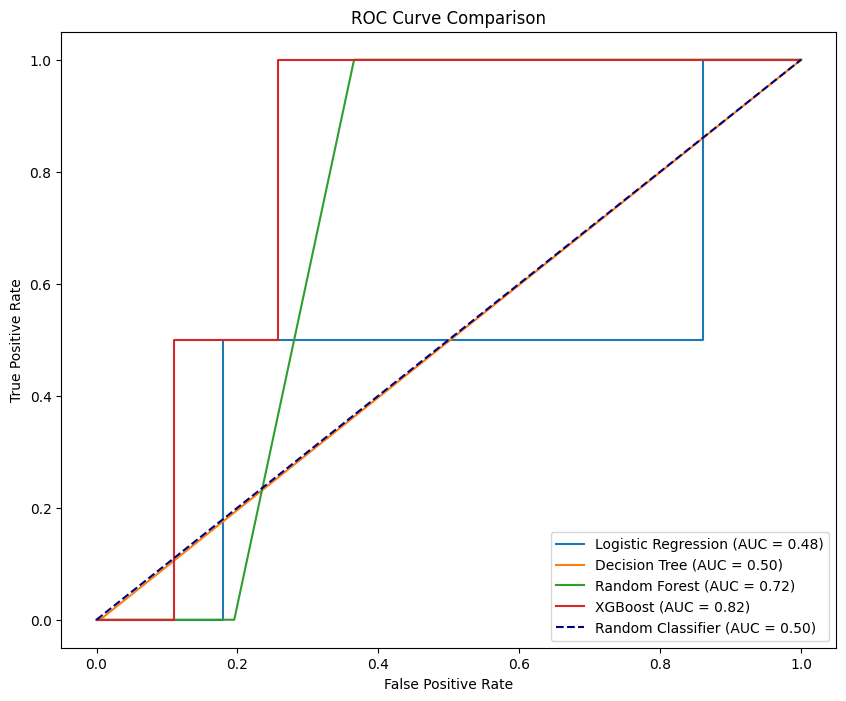

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate ROC-AUC for each model
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # ROC-AUC Score
    if hasattr(model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        print(f"{name} ROC-AUC: {roc_auc:.4f}")

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    else:
        print(f"{name} does not support probability prediction and was skipped.")

# Add diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label="Random Classifier (AUC = 0.50)")

# Add plot details
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

| **Model**               | **ROC-AUC Score** | **Interpretation** |
|--------------------------|-------------------|--------------------|
| **Logistic Regression**  | 0.4791            | Performs worse than random guessing, failing to distinguish classes |
| **Decision Tree**        | 0.4975            | Barely better than random, unreliable for predictions |
| **Random Forest**        | 0.7195            | Captures patterns moderately well, showing reasonable class separation |
| **XGBoost**              | 0.8162            | Strong performance with good ability to separate positive and negative cases |

### Overall Comparison of the Models' Performance
| **Model**               | **ROC-AUC** | **Cross-Validation Score** |
| ----------------------- | ----------- | -------------------------- |
| **Logistic Regression** | 0.4791      | 0.9502                      |
| **Decision Tree** | 0.4975      | 0.9935                      |
| **Random Forest**       | 0.7195      | 0.9988                      |
| **XGBoost**             | 0.8162      | 0.9983                      |

#### Interpretation of Results:
- **Logistic Regression:** Poor discriminatory ability (ROC-AUC < 0.5) despite moderate cross-validation score

- **Decision Tree:** Barely better than random guessing, overfits training data (high CV score vs low ROC-AUC)

- **Random Forest:** Good predictive performance (ROC-AUC ~0.72) with very high cross-validation score, indicating strong learning

- **XGBoost:** Best overall model with highest ROC-AUC (0.8162), slightly lower CV score than Random Forest but better class separation
## Model Chosen: XGBoost

In [26]:
# Save the XGBoost Model
import pickle

with open('xgb.pkl', 'wb') as file:
    pickle.dump(xgb, file)

---
## 7: Interactive Streamlit App
Based on the chosen model (XGBoost) to:
- **Upload .CSV files** for bulk prediction
- **Manually input employees features** for single prediction
- **View prediction results** along with the attrition probability

